## Access Station Lucinda Jetty Hourly Satlantic-Hyperocr (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_hourly_satlantic-hyperocr data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_hourly_satlantic-hyperocr.ipynb).


In [10]:
dataset_name = "station_lucinda_jetty_hourly_satlantic_hyperocr"

## Install/Update packages and Load common functions

In [11]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 448ms
Checked 155 packages in 3ms


✅ Local version 0.3.15 is up to date (remote: 0.3.15)


In [12]:
from DataQuery import GetAodn

# Understanding the Dataset

In [13]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 2.32 s, sys: 4.12 s, total: 6.44 s
Wall time: 8.24 s


In [14]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	WAVELENGTH_Ed = 137 ;
	TIME = 19809430 ;

variables:
	float64 Ed(WAVELENGTH_Ed, TIME) ;
		Ed:ancillary_variables = Ed_quality_control ;
		Ed:description = Downwelling spectral sky irradiance taken at a nadir viewing angle of 0 deg measured from the downward vertical axis. ;
		Ed:long_name = Downwelling spectral sky irradiance ;
		Ed:units = uW/cm^2/nm ;
		Ed:valid_max = 400.0 ;
		Ed:valid_min = 0.0 ;
	float64 Ed_inttime(TIME) ;
		Ed_inttime:description = integration time ;
		Ed_inttime:long_name = integration time ;
		Ed_inttime:units = sec ;
	int32 Ed_quality_control(WAVELENGTH_Ed, TIME) ;
		Ed_quality_control:flag_meanings = No_QC_performed Good_data Probably_good_data Bad_data_that_are_potentially_correctable Bad_data Value_changed Not_used Not_used Not_used Missing_value ;
		Ed_quality_control:flag_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ;
		Ed_quality_control:long_name = quality flag for Downwelling spectral sky irradiance ;
		Ed_quality_control:quali

## Plot time coverage

In [15]:
aodn_dataset.get_temporal_extent()

(Timestamp('2018-01-30 23:36:31.156000'),
 Timestamp('2018-10-16 13:41:54.686000128'))

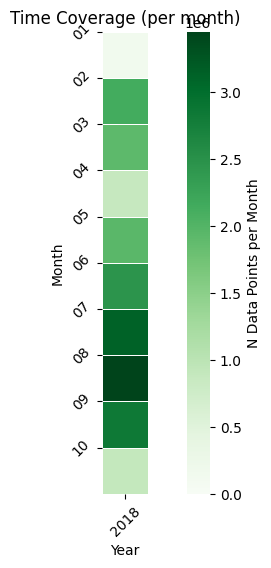

In [16]:
aodn_dataset.plot_time_coverage()

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

xds = aodn_dataset.zarr_store

time_vals = xds["TIME"].values
t_min = pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
t_max = pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")
wl = xds["WAVELENGTH_Ed"].values

print(f"Dataset: {xds.dims['TIME']:,} time steps from {t_min} to {t_max}")
print(f"Wavelength range: {wl.min():.0f}–{wl.max():.0f} nm ({len(wl)} bands, ~{np.diff(wl).mean():.1f} nm spacing)")
print(f"Variables: {list(xds.data_vars)}")
print(xds["Ed"])


Dataset: 10,506,589 time steps from 2018-01-30 to 2018-07-13
Wavelength range: 349–805 nm (137 bands, ~3.4 nm spacing)
Variables: ['Ed', 'Ed_inttime', 'Ed_quality_control', 'Ed_spectemp', 'filename', 'saa', 'sza']
<xarray.DataArray 'Ed' (WAVELENGTH_Ed: 137, TIME: 10506589)> Size: 12GB
dask.array<getitem, shape=(137, 10506589), dtype=float64, chunksize=(137, 5000), chunktype=numpy.ndarray>
Coordinates:
    LATITUDE       float64 8B ...
    LONGITUDE      float64 8B ...
  * TIME           (TIME) datetime64[ns] 84MB 2018-01-30T23:36:31.156000 ... ...
  * WAVELENGTH_Ed  (WAVELENGTH_Ed) float32 548B 348.6 352.0 ... 802.0 805.3
Attributes:
    ancillary_variables:  Ed_quality_control
    description:          Downwelling spectral sky irradiance taken at a nadi...
    long_name:            Downwelling spectral sky irradiance
    units:                uW/cm^2/nm
    valid_max:            400.0
    valid_min:            0.0


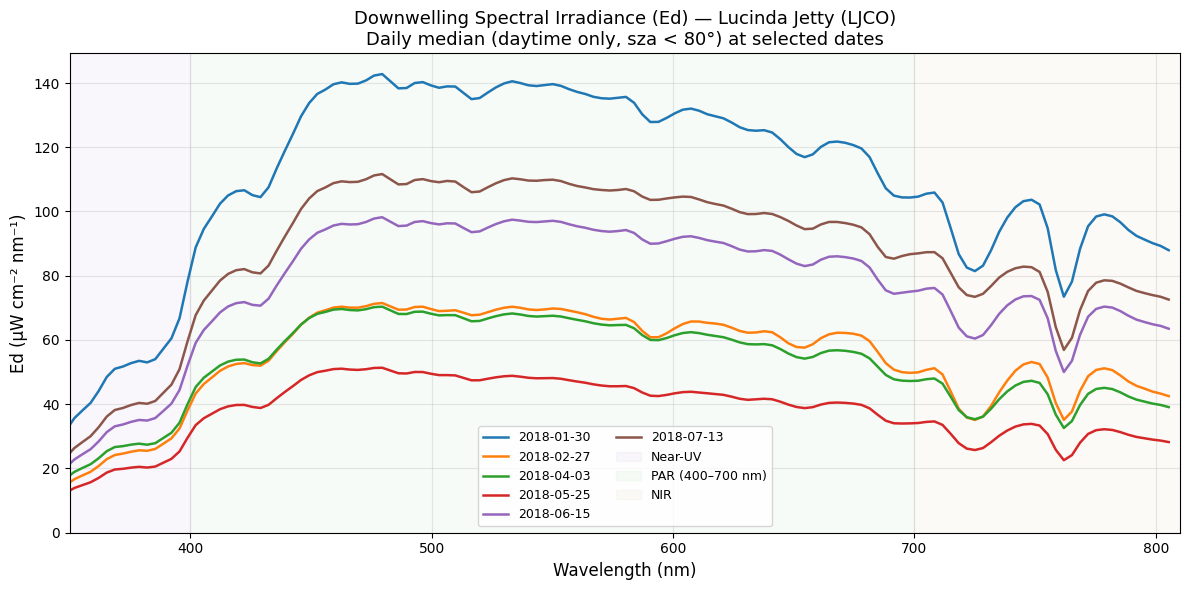

In [9]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl = xds["WAVELENGTH_Ed"].values

# Daily median of Ed and filter to daytime only (sza < 80°)
ed_da  = xds["Ed"].sel(TIME=slice(DATE_START, DATE_END))
sza_da = xds["sza"].sel(TIME=slice(DATE_START, DATE_END))

# Keep only daytime spectra for daily median
ed_day = ed_da.where(sza_da < 80)
ed_daily = ed_day.resample(TIME="1D").median("TIME").astype(float)

# Pick 6 evenly-spaced days with valid data
good_times = ed_daily.TIME.values[
    np.where(~np.all(np.isnan(ed_daily.values), axis=0))[0]
]
n_show = min(6, len(good_times))
pick_idx = np.linspace(0, len(good_times) - 1, n_show, dtype=int)
sample_times = good_times[pick_idx]

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("tab10")

for i, t in enumerate(sample_times):
    spec = ed_daily.sel(TIME=t, method="nearest").values
    label = pd.Timestamp(t).strftime("%Y-%m-%d")
    ax.plot(wl, spec, color=cmap(i), lw=1.8, label=label)

# Spectral region shading
for xlo, xhi, col, lbl in [
    (350, 400, "#c0a0e0", "Near-UV"),
    (400, 700, "#a0d0a0", "PAR (400–700 nm)"),
    (700, 810, "#e0c0a0", "NIR"),
]:
    ax.axvspan(xlo, xhi, alpha=0.08, color=col, label=lbl)

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Ed (μW cm⁻² nm⁻¹)", fontsize=12)
ax.set_title(
    "Downwelling Spectral Irradiance (Ed) — Lucinda Jetty (LJCO)\n"
    "Daily median (daytime only, sza < 80°) at selected dates",
    fontsize=13,
)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
